# Battleship Boardgame with AI - Upgrade Guide

## ปัญหาของ AI เดิม
AI เดิมยิงตาม **static probability list** ที่คำนวณครั้งเดียวตอนโหลด  
→ ไม่ปรับตามสถานการณ์ในเกม (hit/miss) เลย

## 3 วิธีที่จะ Upgrade
| วิธี | ชื่อ | ความฉลาดที่เพิ่ม |
|------|------|------------------|
| 1 | Hunt + Target Mode | ⭐⭐⭐ ยิงรอบๆ ถ้าโดน |
| 2 | Bayesian Probability Map | ⭐⭐⭐⭐ คำนวณ prob ใหม่ทุก turn |
| 3 | Reinforcement Learning (Q-Table) | ⭐⭐⭐⭐⭐ เรียนรู้จากประสบการณ์ |

---
## Install Module For Running Server on Streamlit
---

In [27]:
!pip install -q streamlit
!npm install localtunnel

⠙⠹⠸⠼
up to date, audited 23 packages in 722ms
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠼

---
## Import Dataset For Machine Learning
---

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# โหลดข้อมูลทั้งหมด
df_squares = pd.read_csv('battleship_game_squares.csv')
df_games   = pd.read_csv('battleship_games.csv')
df_moves   = pd.read_csv('battleship_game_moves.csv')

print('=== battleship_game_squares.csv ===')
display(df_squares.head())
print(f'Total rows: {len(df_squares)}')

print('\n=== battleship_games.csv ===')
display(df_games.head())
print(f'Total rows: {len(df_games)}')

print('\n=== battleship_game_moves.csv ===')
display(df_moves.head())

=== battleship_game_squares.csv ===


,id,ai_mode_id,autoplay,ai_win,ai_ships,square,games
0,1,3,0,0,0,1,4561
1,2,3,0,0,0,2,4257
2,3,3,0,0,0,3,4311
3,4,3,0,0,0,4,4069
4,5,3,0,0,0,5,4111


Total rows: 2400

=== battleship_games.csv ===


,id,timestampUTC,ai_win,moves,autoplay,ai_mode_id
0,1,1437141133,1,54,1,2
1,2,1437141331,0,34,0,2
2,3,1437141348,0,39,0,2
3,4,1437141385,1,43,0,2
4,5,1437141617,0,36,0,2


Total rows: 59710

=== battleship_game_moves.csv ===


,id,ai_mode_id,autoplay,ai_win,moves,games
0,1,3,0,0,17,10
1,2,3,0,0,18,1
2,3,3,0,0,19,2
3,4,3,0,0,20,0
4,5,3,0,0,21,3


---
## EDA: วิเคราะห์ข้อมูลก่อน Train Dataset
---

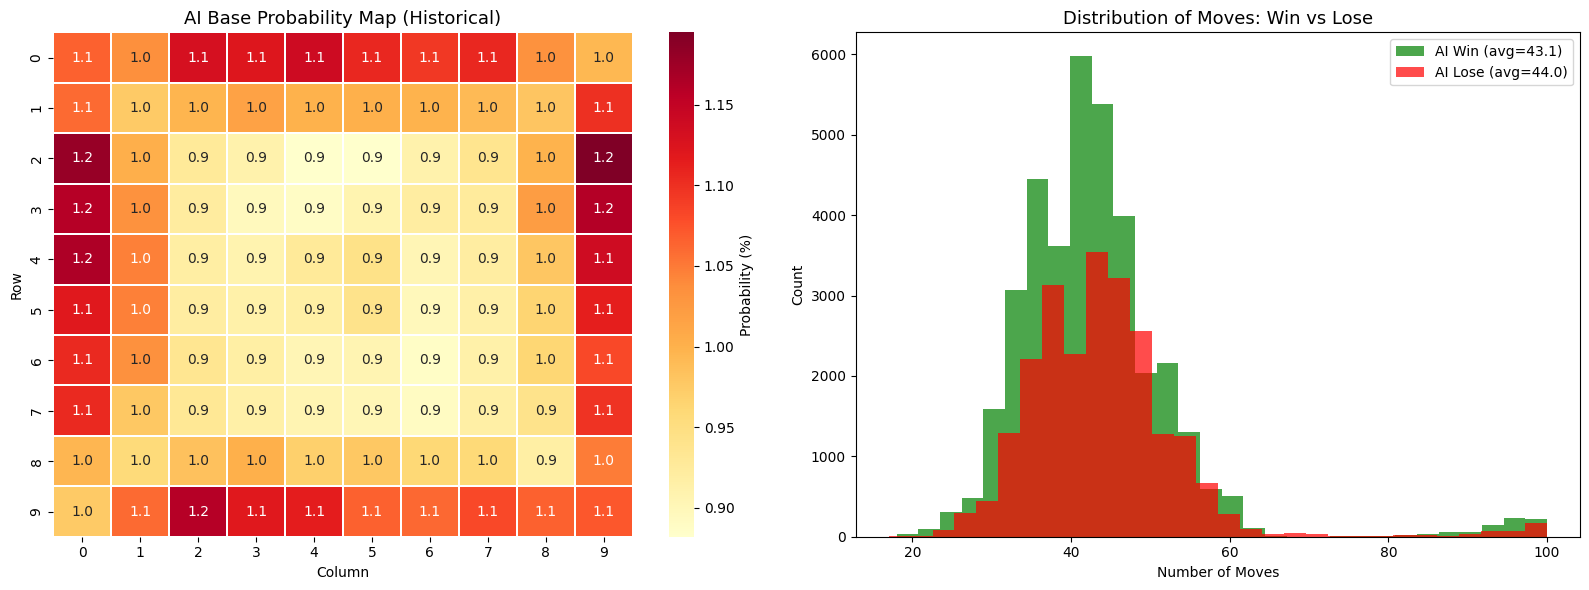

AI Win Rate: 61.1%


In [29]:
# --- สร้าง Base Probability Map จาก CSV (เหมือนเดิม แต่แยก ai_mode) ---
player_data = df_squares[df_squares['ai_ships'] == 0].copy()
stats = player_data.groupby('square')['games'].sum().reset_index()
stats['probability'] = stats['games'] / stats['games'].sum() * 100

board_prob = np.zeros(100)
for _, row in stats.iterrows():
    idx = int(row['square']) - 1
    if 0 <= idx < 100:
        board_prob[idx] = row['probability']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap แบบเดิม
sns.heatmap(board_prob.reshape(10, 10), ax=axes[0],
            cmap='YlOrRd', annot=True, fmt='.1f', linewidths=.3,
            cbar_kws={'label': 'Probability (%)'})
axes[0].set_title('AI Base Probability Map (Historical)', fontsize=13)
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')

# Distribution ของ moves
win_games  = df_games[df_games['ai_win'] == 1]['moves']
lose_games = df_games[df_games['ai_win'] == 0]['moves']
axes[1].hist(win_games,  bins=30, alpha=0.7, label=f'AI Win (avg={win_games.mean():.1f})',  color='green')
axes[1].hist(lose_games, bins=30, alpha=0.7, label=f'AI Lose (avg={lose_games.mean():.1f})', color='red')
axes[1].set_title('Distribution of Moves: Win vs Lose', fontsize=13)
axes[1].set_xlabel('Number of Moves')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"AI Win Rate: {df_games['ai_win'].mean()*100:.1f}%")

---
## Method 1: Hunt + Target Mode
---
**แนวคิด**: แบ่ง AI ออกเป็น 2 โหมด
- **HUNT**: ยิงตาม probability map ปกติ
- **TARGET**: พอโดนเรือแล้ว ให้ยิงช่องรอบๆ เพื่อ "จม" ลำนั้นก่อน

เป็นวิธีที่ **ง่ายที่สุด** แต่ลด moves ได้เยอะมาก

กำลัง Simulate 1,000 เกม...

AI เดิม (Hunt Only):       avg = 95.3 moves (median=97)
AI ใหม่ (Hunt + Target):   avg = 78.6 moves (median=79)
ลดลง: 16.8 moves (17.6%)


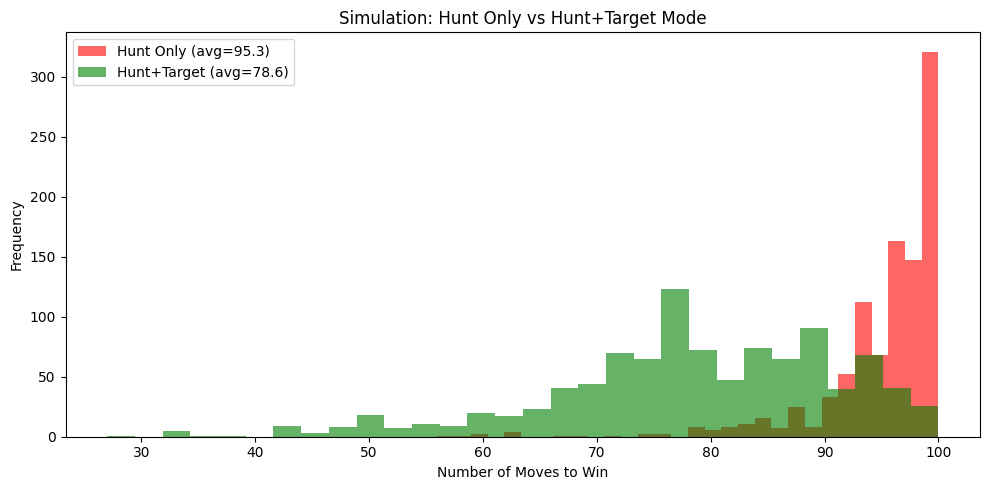

In [30]:
class HuntTargetAI:
    """
    AI แบบ Hunt+Target Mode
    - HUNT  : ยิงตาม base probability map
    - TARGET: หลังโดนเรือ ยิงรอบๆ เพื่อหาทิศทางและจมเรือ
    """
    def __init__(self, base_prob_array):
        # base_prob_array: numpy array shape (100,) ค่า probability ของแต่ละช่อง
        self.base_prob = base_prob_array.copy()
        self.reset()

    def reset(self):
        self.guessed      = set()       # ช่องที่ยิงไปแล้ว
        self.hits         = []          # ช่องที่ยิงโดน (ยังไม่จม)
        self.mode         = 'HUNT'      # 'HUNT' หรือ 'TARGET'
        self.target_queue = []          # คิวช่องที่ต้องยิงใน TARGET mode
        self.last_hit_dir = None        # ทิศทางที่กำลังไล่อยู่

    def _get_neighbors(self, idx):
        """หาช่องรอบๆ (บน ล่าง ซ้าย ขวา)"""
        r, c = idx // 10, idx % 10
        neighbors = []
        if r > 0: neighbors.append((r-1)*10 + c)
        if r < 9: neighbors.append((r+1)*10 + c)
        if c > 0: neighbors.append(r*10 + (c-1))
        if c < 9: neighbors.append(r*10 + (c+1))
        return neighbors

    def _get_aligned_targets(self):
        """ถ้าโดนหลายช่องในแนวเดียวกัน ให้ยิงต่อแนวนั้น"""
        if len(self.hits) < 2:
            return []
        # ตรวจสอบว่าอยู่แนว H หรือ V
        rows = [h // 10 for h in self.hits]
        cols = [h % 10  for h in self.hits]
        targets = []
        if len(set(rows)) == 1:  # แนวนอน
            r = rows[0]
            min_c, max_c = min(cols), max(cols)
            if min_c > 0: targets.append(r*10 + (min_c-1))
            if max_c < 9: targets.append(r*10 + (max_c+1))
        elif len(set(cols)) == 1:  # แนวตั้ง
            c = cols[0]
            min_r, max_r = min(rows), max(rows)
            if min_r > 0: targets.append((min_r-1)*10 + c)
            if max_r < 9: targets.append((max_r+1)*10 + c)
        return targets

    def choose_target(self):
        """เลือกช่องที่จะยิงต่อไป"""
        # --- TARGET MODE ---
        if self.mode == 'TARGET' and self.hits:
            # ลองยิงตามแนวก่อน
            aligned = self._get_aligned_targets()
            for sq in aligned:
                if sq not in self.guessed:
                    return sq
            # ถ้าไม่มี ยิงรอบๆ hit ล่าสุด
            for sq in self.target_queue:
                if sq not in self.guessed:
                    return sq
            # ถ้า queue หมด กลับ HUNT
            self.mode = 'HUNT'
            self.hits = []
            self.target_queue = []

        # --- HUNT MODE: เลือกตาม probability สูงสุด ---
        prob_copy = self.base_prob.copy()
        prob_copy[list(self.guessed)] = -1  # ยิงไปแล้ว
        return int(np.argmax(prob_copy))

    def register_result(self, idx, is_hit, ship_sunk=False):
        """บันทึกผลการยิง"""
        self.guessed.add(idx)
        if is_hit:
            self.hits.append(idx)
            self.mode = 'TARGET'
            # เพิ่มช่องรอบๆ ใน queue
            for nb in self._get_neighbors(idx):
                if nb not in self.guessed and nb not in self.target_queue:
                    self.target_queue.append(nb)
            if ship_sunk:
                # เรือจม: เคลียร์สถานะ Target
                self.hits = []
                self.target_queue = []
                self.mode = 'HUNT'


# ========== ทดสอบ Simulation ==========
SHIP_LENGTHS = [5, 4, 3, 3, 2]

def random_board():
    """สร้างกระดานวางเรือแบบสุ่ม"""
    board = np.zeros(100, dtype=int)
    ship_cells = defaultdict(list)
    for i, length in enumerate(SHIP_LENGTHS):
        placed = False
        while not placed:
            ori = random.choice(['H', 'V'])
            if ori == 'H':
                r, c = random.randint(0, 9), random.randint(0, 10-length)
                cells = [r*10 + c+j for j in range(length)]
            else:
                r, c = random.randint(0, 10-length), random.randint(0, 9)
                cells = [(r+j)*10 + c for j in range(length)]
            if all(board[cell] == 0 for cell in cells):
                for cell in cells:
                    board[cell] = i+1  # บันทึกหมายเลขเรือ
                ship_cells[i] = cells
                placed = True
    return board, ship_cells

def simulate(ai, n_games=1000):
    """Simulate n_games แล้วคืน avg moves"""
    total_ships = sum(SHIP_LENGTHS)
    moves_list = []
    for _ in range(n_games):
        board, ship_cells = random_board()
        sunk = set()
        ai.reset()
        moves = 0
        hits = 0
        while hits < total_ships:
            sq = ai.choose_target()
            moves += 1
            is_hit = board[sq] > 0
            ship_idx = board[sq] - 1 if is_hit else -1
            ship_sunk = False
            if is_hit:
                hits += 1
                ship_sunk = all(s in ai.guessed | {sq} for s in ship_cells[ship_idx]) if ship_idx >= 0 else False
                if ship_sunk:
                    sunk.add(ship_idx)
            ai.register_result(sq, is_hit, ship_sunk)
        moves_list.append(moves)
    return moves_list


# สร้าง AI เดิม (HUNT only)
top_targets_sorted = stats.sort_values('probability', ascending=False)['square'].values
hunt_only_prob = np.zeros(100)
for rank, sq in enumerate(top_targets_sorted):
    idx = int(sq) - 1
    if 0 <= idx < 100:
        # ให้ prob สูงสุดกับอันดับแรก
        hunt_only_prob[idx] = (100 - rank) / 100

ai_old   = HuntTargetAI(board_prob)
ai_old.mode = 'HUNT'  # Force HUNT only (ปิด target)
ai_new   = HuntTargetAI(board_prob)  # Hunt + Target

print('กำลัง Simulate 1,000 เกม...')
old_class = type('HuntOnly', (), {
    'base_prob': board_prob.copy(),
    'guessed': set(),
    'reset': lambda self: setattr(self, 'guessed', set()),
    'choose_target': lambda self: int(np.argmax(np.where(np.array([i in self.guessed for i in range(100)]), -1, self.base_prob))),
    'register_result': lambda self, idx, *args: self.guessed.add(idx)
})()

moves_old = simulate(old_class, 1000)
moves_new = simulate(ai_new, 1000)

print(f"\nAI เดิม (Hunt Only):       avg = {np.mean(moves_old):.1f} moves (median={np.median(moves_old):.0f})")
print(f"AI ใหม่ (Hunt + Target):   avg = {np.mean(moves_new):.1f} moves (median={np.median(moves_new):.0f})")
print(f"ลดลง: {np.mean(moves_old)-np.mean(moves_new):.1f} moves ({(np.mean(moves_old)-np.mean(moves_new))/np.mean(moves_old)*100:.1f}%)")

plt.figure(figsize=(10, 5))
plt.hist(moves_old, bins=30, alpha=0.6, label=f'Hunt Only (avg={np.mean(moves_old):.1f})',   color='red')
plt.hist(moves_new, bins=30, alpha=0.6, label=f'Hunt+Target (avg={np.mean(moves_new):.1f})', color='green')
plt.xlabel('Number of Moves to Win')
plt.ylabel('Frequency')
plt.title('Simulation: Hunt Only vs Hunt+Target Mode')
plt.legend()
plt.tight_layout()
plt.show()

---
## Method 2: Bayesian Probability Map (Dynamic)
---
**แนวคิด**: หลังยิงแต่ละครั้ง คำนวณ probability map ใหม่ทั้งกระดาน  
โดยนับว่า **"ช่องไหนที่เรือทุกลำยังวางได้"** → ช่องนั้นมี probability สูง

เป็นวิธีที่ **ฉลาดที่สุดเชิงสถิติ** เพราะใช้ข้อมูลจากการยิงทุกครั้งในเกมนั้น

กำลัง Simulate 500 เกม (ใช้เวลานานขึ้น)...
Hunt+Target:       avg = 79.2 moves
Bayesian Map:      avg = 47.3 moves
ลดลงอีก: 31.9 moves


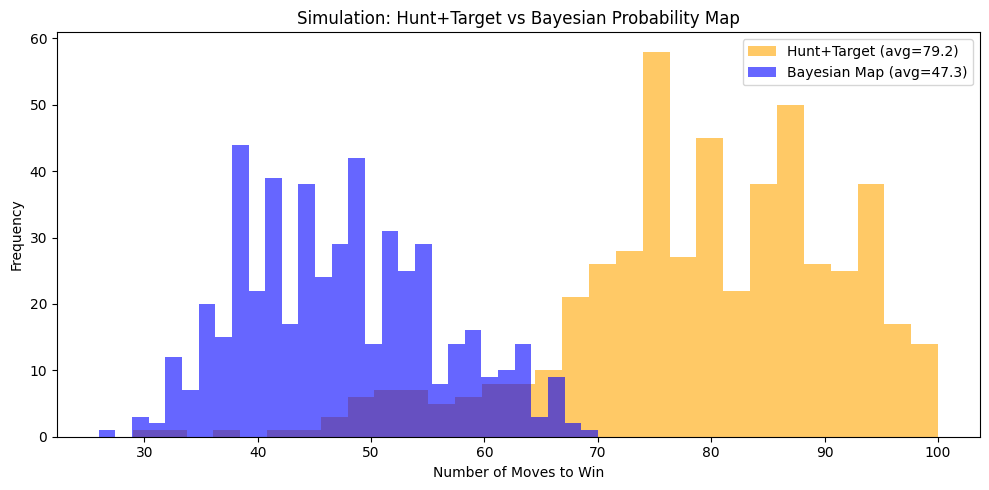

In [31]:
class BayesianAI:
    """
    AI แบบ Bayesian Probability Density
    - คำนวณใหม่ทุกรอบว่า ช่องไหน 'เป็นไปได้' ที่สุดที่จะมีเรือ
    - รวมกับ Hunt+Target เพื่อจัดการหลังโดนเรือ
    """
    SHIP_LENGTHS = [5, 4, 3, 3, 2]

    def __init__(self, base_prob_weight=0.3):
        # base_prob_weight: น้ำหนักของ historical probability (0 = pure Bayes)
        self.base_prob_weight = base_prob_weight
        self.reset()

    def reset(self):
        self.guessed       = set()
        self.hit_squares   = set()
        self.miss_squares  = set()
        self.sunk_squares  = set()
        self.remaining_lengths = list(self.SHIP_LENGTHS)
        self.mode          = 'HUNT'
        self.target_queue  = []
        self.active_hits   = []  # hits ของเรือปัจจุบันที่กำลังไล่

    def _compute_probability_map(self):
        """คำนวณ probability ใหม่ทุกรอบ"""
        prob = np.zeros(100)
        # นับว่าแต่ละช่องถูก 'ครอบคลุม' โดยตำแหน่งที่เรือยังวางได้กี่แบบ
        for length in self.remaining_lengths:
            for r in range(10):
                for c in range(10 - length + 1):  # แนวนอน
                    cells = [r*10 + c+j for j in range(length)]
                    # Valid ถ้า: ไม่มี miss, ถ้ามี active_hits ต้องครอบคลุมอย่างน้อย 1 hit
                    if all(cell not in self.miss_squares and cell not in self.sunk_squares for cell in cells):
                        if not self.active_hits or any(h in cells for h in self.active_hits):
                            for cell in cells:
                                if cell not in self.guessed:
                                    prob[cell] += 1
                for r2 in range(10 - length + 1):  # แนวตั้ง
                    cells = [(r2+j)*10 + r for j in range(length)]  # r ใช้เป็น column
                    if all(cell not in self.miss_squares and cell not in self.sunk_squares for cell in cells):
                        if not self.active_hits or any(h in cells for h in self.active_hits):
                            for cell in cells:
                                if cell not in self.guessed:
                                    prob[cell] += 1
        # Normalize
        total = prob.sum()
        if total > 0:
            prob = prob / total
        return prob

    def choose_target(self):
        prob = self._compute_probability_map()
        # ช่องที่ยิงแล้วไม่เลือก
        prob[list(self.guessed)] = 0
        return int(np.argmax(prob))

    def register_result(self, idx, is_hit, ship_sunk=False, sunk_cells=None):
        self.guessed.add(idx)
        if is_hit:
            self.hit_squares.add(idx)
            self.active_hits.append(idx)
            self.mode = 'TARGET'
            if ship_sunk:
                if sunk_cells:
                    self.sunk_squares.update(sunk_cells)
                    ship_len = len(sunk_cells)
                else:
                    ship_len = len(self.active_hits)
                # ลบความยาวเรือที่จมออก
                if ship_len in self.remaining_lengths:
                    self.remaining_lengths.remove(ship_len)
                self.active_hits = []
                self.mode = 'HUNT'
        else:
            self.miss_squares.add(idx)


# ทดสอบ
ai_bayes = BayesianAI()

def simulate_bayes(ai, n_games=500):
    total_ships = sum(SHIP_LENGTHS)
    moves_list = []
    for _ in range(n_games):
        board, ship_cells = random_board()
        ai.reset()
        hits = 0
        moves = 0
        while hits < total_ships:
            sq = ai.choose_target()
            moves += 1
            is_hit = board[sq] > 0
            ship_idx = board[sq] - 1 if is_hit else -1
            ship_sunk = False
            sunk_cells = None
            if is_hit:
                hits += 1
                if ship_idx >= 0 and all(s in ai.guessed | {sq} for s in ship_cells[ship_idx]):
                    ship_sunk = True
                    sunk_cells = ship_cells[ship_idx]
            ai.register_result(sq, is_hit, ship_sunk, sunk_cells)
        moves_list.append(moves)
    return moves_list

print('กำลัง Simulate 500 เกม (ใช้เวลานานขึ้น)...')
moves_hunt = simulate(ai_new, 500)
moves_bayes = simulate_bayes(ai_bayes, 500)

print(f"Hunt+Target:       avg = {np.mean(moves_hunt):.1f} moves")
print(f"Bayesian Map:      avg = {np.mean(moves_bayes):.1f} moves")
print(f"ลดลงอีก: {np.mean(moves_hunt)-np.mean(moves_bayes):.1f} moves")

plt.figure(figsize=(10, 5))
plt.hist(moves_hunt,  bins=30, alpha=0.6, label=f'Hunt+Target (avg={np.mean(moves_hunt):.1f})',  color='orange')
plt.hist(moves_bayes, bins=30, alpha=0.6, label=f'Bayesian Map (avg={np.mean(moves_bayes):.1f})', color='blue')
plt.xlabel('Number of Moves to Win')
plt.ylabel('Frequency')
plt.title('Simulation: Hunt+Target vs Bayesian Probability Map')
plt.legend()
plt.tight_layout()
plt.show()

---
## Method 3: Q-Learning (Reinforcement Learning)
---
**แนวคิด**: ให้ AI เรียนรู้จากประสบการณ์เองว่า **ช่องไหนน่ายิงมากที่สุด**  
ตาม state ของกระดาน ณ ขณะนั้น (ไม่ใช่แค่สถิติรวม)

เราใช้ข้อมูลใน CSV มา **initialize Q-table** ก่อน จากนั้นให้มัน **self-play** ต่อ



Training Q-Learning AI...
  Episode   2000/20000  |  Avg moves (last 500): 74.3  |  ε=0.050
  Episode   4000/20000  |  Avg moves (last 500): 75.7  |  ε=0.050
  Episode   6000/20000  |  Avg moves (last 500): 74.5  |  ε=0.050
  Episode   8000/20000  |  Avg moves (last 500): 74.9  |  ε=0.050
  Episode  10000/20000  |  Avg moves (last 500): 73.3  |  ε=0.050
  Episode  12000/20000  |  Avg moves (last 500): 73.1  |  ε=0.050
  Episode  14000/20000  |  Avg moves (last 500): 74.1  |  ε=0.050
  Episode  16000/20000  |  Avg moves (last 500): 75.3  |  ε=0.050
  Episode  18000/20000  |  Avg moves (last 500): 74.3  |  ε=0.050
  Episode  20000/20000  |  Avg moves (last 500): 74.0  |  ε=0.050

Training เสร็จแล้ว!


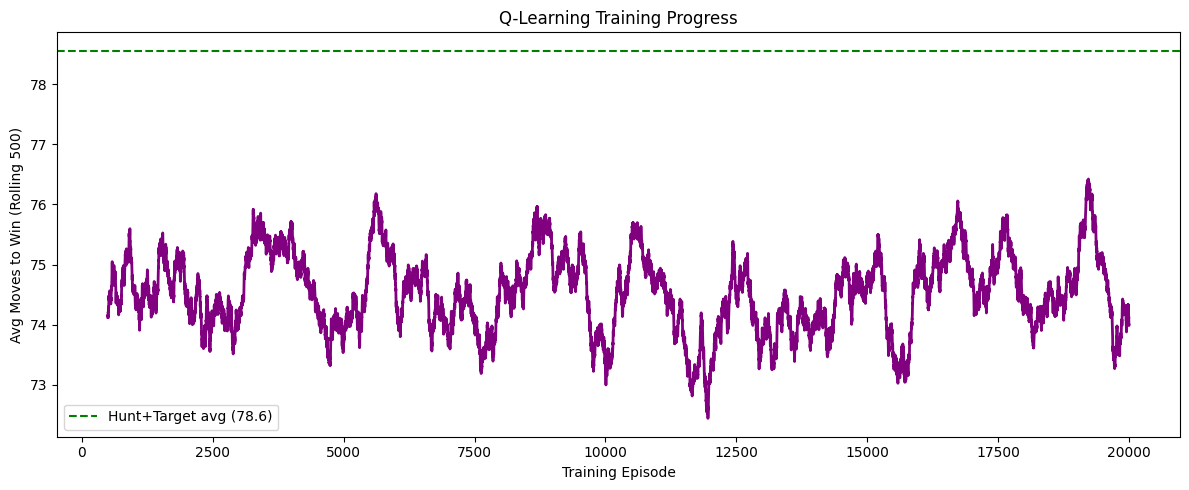

In [32]:
class QLearningAI:
    """
    Q-Learning AI สำหรับ Battleship
    State  : tuple ของช่องที่ยิงไปแล้ว (ใช้ simplified state เพื่อประหยัด memory)
    Action : ช่องที่จะยิง (0-99)
    Reward : +10 = โดน, +50 = จม, -1 = พลาด
    """
    def __init__(self, base_prob=None, alpha=0.1, gamma=0.9,
                 epsilon=1.0, epsilon_decay=0.9995, epsilon_min=0.05):
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min

        # Q-table: q_values[square] = expected reward
        # (Simplified: ไม่ขึ้นกับ full state ทั้งกระดาน เพราะ state space ใหญ่มาก)
        # ใช้ base_prob เป็น initial value
        if base_prob is not None:
            self.q_values = base_prob.copy() * 10  # scale ให้ใหญ่ขึ้น
        else:
            self.q_values = np.ones(100) * 5.0

        self.reset()

    def reset(self):
        self.guessed     = set()
        self.hits        = []
        self.active_hits = []
        self.mode        = 'HUNT'

    def _get_neighbors(self, idx):
        r, c = idx // 10, idx % 10
        nb = []
        if r > 0: nb.append((r-1)*10 + c)
        if r < 9: nb.append((r+1)*10 + c)
        if c > 0: nb.append(r*10 + (c-1))
        if c < 9: nb.append(r*10 + (c+1))
        return nb

    def choose_target(self, training=True):
        # Epsilon-greedy
        valid = [i for i in range(100) if i not in self.guessed]
        if not valid:
            return 0

        if self.mode == 'TARGET' and self.active_hits:
            # Priority: ยิงรอบๆ hit ก่อน
            neighbors = []
            for h in self.active_hits:
                for nb in self._get_neighbors(h):
                    if nb not in self.guessed and nb not in neighbors:
                        neighbors.append(nb)
            if neighbors:
                # เลือกตาม Q-value
                best = max(neighbors, key=lambda x: self.q_values[x])
                return best

        if training and random.random() < self.epsilon:
            return random.choice(valid)
        return max(valid, key=lambda x: self.q_values[x])

    def update(self, sq, reward, next_valid):
        """อัปเดต Q-value ด้วย Q-learning formula"""
        if next_valid:
            max_next = max(self.q_values[i] for i in next_valid)
        else:
            max_next = 0
        self.q_values[sq] += self.alpha * (reward + self.gamma * max_next - self.q_values[sq])
        # Decay epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def register_result(self, idx, is_hit, ship_sunk=False):
        self.guessed.add(idx)
        if is_hit:
            self.active_hits.append(idx)
            self.mode = 'TARGET'
            if ship_sunk:
                self.active_hits = []
                self.mode = 'HUNT'


# ========== Train Q-Learning ==========
print('Training Q-Learning AI...')
total_ships = sum(SHIP_LENGTHS)
ai_ql = QLearningAI(base_prob=board_prob)

N_TRAIN = 20000
train_moves = []
window = 500

for episode in range(N_TRAIN):
    board, ship_cells = random_board()
    ai_ql.reset()
    hits = 0
    moves = 0

    while hits < total_ships:
        sq = ai_ql.choose_target(training=True)
        moves += 1
        is_hit = board[sq] > 0
        ship_idx = board[sq] - 1 if is_hit else -1
        ship_sunk = False

        if is_hit:
            hits += 1
            ship_sunk = ship_idx >= 0 and all(s in ai_ql.guessed | {sq} for s in ship_cells[ship_idx])

        # Reward
        if ship_sunk:   reward = 50
        elif is_hit:    reward = 10
        else:           reward = -1

        next_valid = [i for i in range(100) if i not in ai_ql.guessed and i != sq]
        ai_ql.update(sq, reward, next_valid)
        ai_ql.register_result(sq, is_hit, ship_sunk)

    train_moves.append(moves)
    if (episode+1) % 2000 == 0:
        avg = np.mean(train_moves[-window:])
        print(f"  Episode {episode+1:>6}/{N_TRAIN}  |  Avg moves (last {window}): {avg:.1f}  |  ε={ai_ql.epsilon:.3f}")

print('\nTraining เสร็จแล้ว!')

# --- Plot Training Progress ---
rolling_avg = pd.Series(train_moves).rolling(window=500).mean()
plt.figure(figsize=(12, 5))
plt.plot(rolling_avg, color='purple', linewidth=2)
plt.axhline(y=np.mean(moves_new), color='green', linestyle='--', label=f'Hunt+Target avg ({np.mean(moves_new):.1f})')
plt.xlabel('Training Episode')
plt.ylabel('Avg Moves to Win (Rolling 500)')
plt.title('Q-Learning Training Progress')
plt.legend()
plt.tight_layout()
plt.show()

AI Version                      Avg Moves   Median
Hunt Only (เดิม)                     95.3       97
Hunt + Target                        79.2       81
Bayesian Probability                 47.3       47
Q-Learning (Trained)                 75.5       77


/tmp/ipykernel_4579/87410017.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
/tmp/ipykernel_4579/87410017.py:54: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4579/87410017.py:54: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4579/87410017.py:54: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4579/87410017.py:54: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4579/87410017.py:54: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykerne

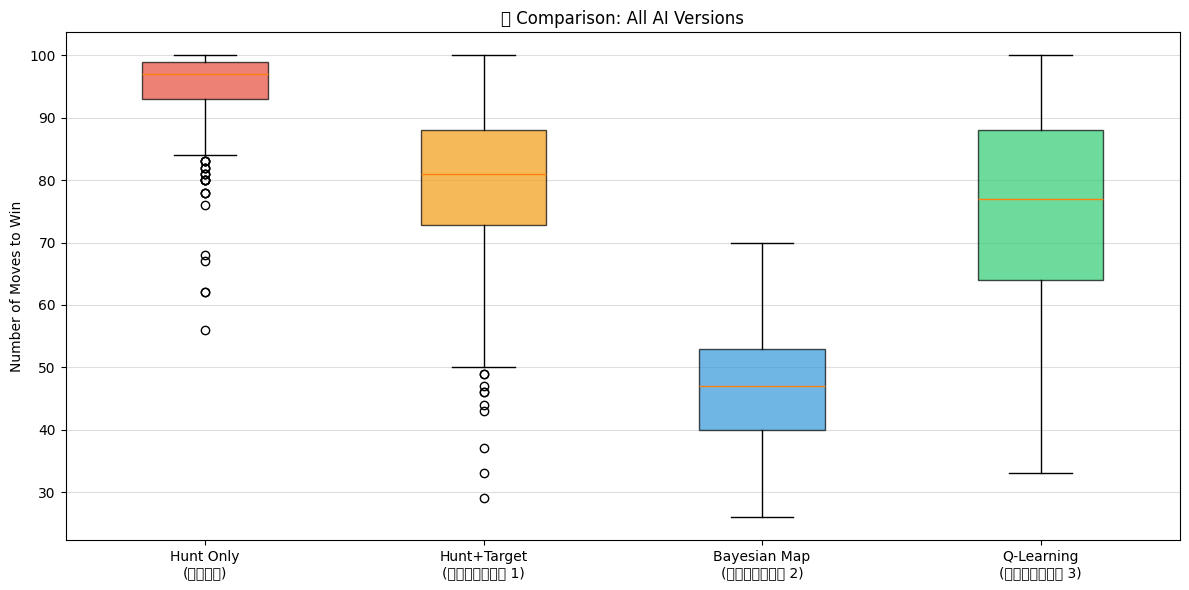

In [33]:
# --- Test Q-Learning (ปิด exploration) ---
ai_ql.epsilon = 0  # Pure exploitation

def simulate_ql(ai, n_games=500):
    total_ships = sum(SHIP_LENGTHS)
    moves_list = []
    for _ in range(n_games):
        board, ship_cells = random_board()
        ai.reset()
        hits = 0
        moves = 0
        while hits < total_ships:
            sq = ai.choose_target(training=False)
            moves += 1
            is_hit = board[sq] > 0
            ship_idx = board[sq] - 1 if is_hit else -1
            ship_sunk = False
            if is_hit:
                hits += 1
                ship_sunk = ship_idx >= 0 and all(s in ai.guessed | {sq} for s in ship_cells[ship_idx])
            ai.register_result(sq, is_hit, ship_sunk)
        moves_list.append(moves)
    return moves_list

moves_ql = simulate_ql(ai_ql, 500)

# --- เปรียบเทียบทุกวิธี ---
print('=' * 55)
print(f"{'AI Version':<30} {'Avg Moves':>10} {'Median':>8}")
print('=' * 55)
for name, data in [
    ('Hunt Only (เดิม)',       moves_old[:500]),
    ('Hunt + Target',          moves_hunt),
    ('Bayesian Probability',   moves_bayes),
    ('Q-Learning (Trained)',   moves_ql),
]:
    print(f"{name:<30} {np.mean(data):>10.1f} {np.median(data):>8.0f}")
print('=' * 55)

# Boxplot เปรียบเทียบ
plt.figure(figsize=(12, 6))
data_to_plot = [moves_old[:500], moves_hunt, moves_bayes, moves_ql]
labels       = ['Hunt Only\n(เดิม)', 'Hunt+Target\n(วิธีที่ 1)', 'Bayesian Map\n(วิธีที่ 2)', 'Q-Learning\n(วิธีที่ 3)']
colors       = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

bp = plt.boxplot(data_to_plot, patch_artist=True, labels=labels)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Number of Moves to Win')
plt.title('📊 Comparison: All AI Versions')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Implement Hunt+Target to Streamlit App
นำ `HuntTargetAI` ที่ดีที่สุดไป **แทนที่ `get_ai_next_move`** ใน `app.py`

In [36]:
%%writefile app.py
import streamlit as st
import streamlit.components.v1 as components
import pandas as pd
import numpy as np
import random
import os

# --- ตั้งค่าหน้าเว็บ ---
st.set_page_config(page_title="Battleship AI", layout="wide")

st.markdown("""
    <style>
    div[data-testid="stButton"] button {
        width: 100%;
        height: 3em;
        padding: 0px;
        margin: 0px;
    }
    </style>
""", unsafe_allow_html=True)

st.title("🚢 Battleship: Human vs AI")

# --- ข้อมูลกองเรือ ---
FLEET = {
    "Carrier (5 ช่อง)": 5,
    "Battleship (4 ช่อง)": 4,
    "Cruiser (3 ช่อง)": 3,
    "Submarine (3 ช่อง)": 3,
    "Destroyer (2 ช่อง)": 2
}
SHIPS_NEEDED = sum(FLEET.values())


# ============================================================
# 🔴 จุดที่ 1: แทนที่ load_ai_logic() ด้วย HuntTargetAI class
# ลบโค้ดเดิมทั้งหมดในส่วนนี้ แล้ววางโค้ดด้านล่างแทน
# ============================================================

class HuntTargetAI:
    """
    AI แบบ Hunt + Target + Bayesian Update
    - HUNT   : ยิงตาม live_prob ที่ปรับตาม evidence ทุก turn
    - TARGET : พอโดนเรือแล้ว ไล่ยิงรอบๆ เพื่อจมเรือ
    - BAYES  : ทุกครั้งที่ยิงพลาด จะลด prob ของช่องนั้น + รอบข้าง
                ทำให้ AI ค่อยๆ เลิกเลือกขอบถ้าขอบพลาดหลายครั้ง
    """

    # น้ำหนัก miss penalty: ช่องที่พลาดโดยตรง และรอบข้าง
    MISS_DIRECT   = 0.0   # ลดเป็น 0 (ยิงไปแล้ว ไม่เลือกซ้ำ)
    MISS_NEIGHBOR = 0.55  # ลด prob รอบข้าง 45%

    def __init__(self, base_prob_array):
        self.base_prob = base_prob_array.copy()
        self.reset()

    def reset(self):
        self.guessed     = set()
        self.active_hits = []
        self.mode        = 'HUNT'
        # live_prob: copy ของ base_prob ที่ปรับตาม evidence ในเกมนี้
        self.live_prob   = self.base_prob.copy()

    def _neighbors(self, idx):
        r, c = idx // 10, idx % 10
        nb = []
        if r > 0: nb.append((r - 1) * 10 + c)
        if r < 9: nb.append((r + 1) * 10 + c)
        if c > 0: nb.append(r * 10 + (c - 1))
        if c < 9: nb.append(r * 10 + (c + 1))
        return nb

    def _aligned_targets(self):
        if len(self.active_hits) < 2:
            return []
        rows = [h // 10 for h in self.active_hits]
        cols = [h % 10  for h in self.active_hits]
        targets = []
        if len(set(rows)) == 1:
            r = rows[0]; mc, xc = min(cols), max(cols)
            if mc > 0: targets.append(r * 10 + mc - 1)
            if xc < 9: targets.append(r * 10 + xc + 1)
        elif len(set(cols)) == 1:
            c = cols[0]; mr, xr = min(rows), max(rows)
            if mr > 0: targets.append((mr - 1) * 10 + c)
            if xr < 9: targets.append((xr + 1) * 10 + c)
        return targets

    def _bayesian_miss_update(self, idx):
        """
        Bayesian update เมื่อยิงพลาด:
        ลด live_prob ของช่องรอบข้าง เพื่อให้ AI รู้ว่า
        บริเวณนั้นน่าจะไม่มีเรือ และหันมาเลือกบริเวณอื่นแทน
        """
        # ลด prob ของช่องรอบข้าง
        for nb in self._neighbors(idx):
            if nb not in self.guessed:
                self.live_prob[nb] *= self.MISS_NEIGHBOR
        # normalize ให้ prob รวม = 1 (ยกเว้นช่องที่ยิงไปแล้ว)
        remaining = [i for i in range(100) if i not in self.guessed]
        total = sum(self.live_prob[i] for i in remaining)
        if total > 0:
            factor = 1.0 / total
            for i in remaining:
                self.live_prob[i] *= factor

    def choose_target(self):
        # TARGET mode: ไล่จมเรือที่โดนแล้ว
        if self.mode == 'TARGET' and self.active_hits:
            for sq in self._aligned_targets():
                if sq not in self.guessed:
                    return sq
            for h in self.active_hits:
                for nb in self._neighbors(h):
                    if nb not in self.guessed:
                        return nb
            self.mode = 'HUNT'
            self.active_hits = []

        # HUNT mode: เลือกตาม live_prob ที่ปรับแล้ว
        prob = self.live_prob.copy()
        prob[list(self.guessed)] = -1
        return int(np.argmax(prob))

    def register_result(self, idx, is_hit, ship_sunk=False, sunk_cells=None):
        """
        บันทึกผลการยิง + อัปเดต Bayesian probability

        sunk_cells: list of (r, c) ของเรือที่จมในเทิร์นนี้
                    ถ้าไม่ส่งมา จะ clear active_hits ทั้งหมด (fallback)

        Bug ที่แก้: ถ้า active_hits มี hit ของเรือ 2 ลำ และลำแรกจม
        เดิม → clear active_hits ทั้งหมด ลืม hit ของลำที่ 2
        ใหม่ → ลบเฉพาะ cells ของลำที่จม เหลือ hit ของลำที่ 2 ไว้ใน TARGET mode
        """
        self.guessed.add(idx)
        self.live_prob[idx] = 0

        if is_hit:
            self.active_hits.append(idx)
            self.mode = 'TARGET'
            if ship_sunk:
                if sunk_cells:
                    sunk_idx_set = {r * 10 + c for r, c in sunk_cells}
                    self.active_hits = [h for h in self.active_hits
                                        if h not in sunk_idx_set]
                else:
                    self.active_hits = []
                if not self.active_hits:
                    self.mode = 'HUNT'
        else:
            self._bayesian_miss_update(idx)


@st.cache_data
def load_base_prob():
    """โหลด probability map จาก CSV (cache ไว้ไม่ต้องโหลดซ้ำ)"""
    base_prob = np.ones(100) / 100  # uniform fallback
    if os.path.exists('battleship_game_squares.csv'):
        df = pd.read_csv('battleship_game_squares.csv')
        player_data = df[df['ai_ships'] == 0]
        stats = player_data.groupby('square')['games'].sum().reset_index()
        total = stats['games'].sum()
        for _, row in stats.iterrows():
            idx = int(row['square']) - 1
            if 0 <= idx < 100:
                base_prob[idx] = row['games'] / total
    return base_prob

# ============================================================
# 🔴 จุดที่ 2: แก้ส่วน session_state init
# ลบ: ai_targets และ ai_guess_index
# เพิ่ม: ai_brain (HuntTargetAI object)
# ============================================================

if 'phase' not in st.session_state:
    st.session_state.phase = 'setup'
    st.session_state.player_board = np.zeros((10, 10), dtype=int)
    st.session_state.ai_board = np.zeros((10, 10), dtype=int)
    st.session_state.player_shots = {}
    st.session_state.ai_shots = {}

    # --- เดิม: ai_targets = load_ai_logic(), ai_guess_index = 0 ---
    # --- ใหม่: สร้าง HuntTargetAI object เก็บใน session_state ---
    st.session_state.ai_brain = HuntTargetAI(load_base_prob())

    st.session_state.message = "👉 กรุณาวางเรือของคุณที่กระดานฝั่งซ้ายมือ"
    st.session_state.player_ships_placed = []
    st.session_state.setup_error = ""
    st.session_state.ship_orientation = 'แนวนอน (👉)'  # ค่าเริ่มต้น
    st.session_state.player_ships_coords = {}
    st.session_state.ai_ships_coords = {}
    st.session_state.player_sunk_ships = []
    st.session_state.ai_sunk_ships = []


def random_place_ships(board_array, coords_dict):
    board_array.fill(0)
    coords_dict.clear()
    for ship_name, length in FLEET.items():
        placed = False
        while not placed:
            r, c = random.randint(0, 9), random.randint(0, 9)
            ori = random.choice(['H', 'V'])
            if ori == 'H' and c + length <= 10 and all(board_array[r, c+i] == 0 for i in range(length)):
                coords_dict[ship_name] = []
                for i in range(length):
                    board_array[r, c+i] = 1
                    coords_dict[ship_name].append((r, c+i))
                placed = True
            elif ori == 'V' and r + length <= 10 and all(board_array[r+i, c] == 0 for i in range(length)):
                coords_dict[ship_name] = []
                for i in range(length):
                    board_array[r+i, c] = 1
                    coords_dict[ship_name].append((r+i, c))
                placed = True


def place_ship_cb(r, c, ship_name, length):
    st.session_state.setup_error = ""
    orientation = st.session_state.get("ship_orientation", "แนวนอน (👉)")

    valid = True
    if orientation == 'แนวนอน (👉)':
        if c + length > 10: valid = False
        elif any(st.session_state.player_board[r, c+i] == 1 for i in range(length)): valid = False
    else:
        if r + length > 10: valid = False
        elif any(st.session_state.player_board[r+i, c] == 1 for i in range(length)): valid = False

    if valid:
        st.session_state.player_ships_coords[ship_name] = []
        if orientation == 'แนวนอน (👉)':
            for i in range(length):
                st.session_state.player_board[r, c+i] = 1
                st.session_state.player_ships_coords[ship_name].append((r, c+i))
        else:
            for i in range(length):
                st.session_state.player_board[r+i, c] = 1
                st.session_state.player_ships_coords[ship_name].append((r+i, c))
        st.session_state.player_ships_placed.append(ship_name)
    else:
        st.session_state.setup_error = "⚠️ วางตรงนี้ไม่ได้ครับ! เรืออาจจะล้นขอบกระดานหรือทับกับลำอื่น"


def check_sunk_ships(ships_coords, shots_dict, sunk_list):
    newly_sunk = None
    for ship_name, coords in ships_coords.items():
        if ship_name not in sunk_list:
            if all(shots_dict.get(pos) == 'hit' for pos in coords):
                sunk_list.append(ship_name)
                newly_sunk = ship_name
    return newly_sunk


# ============================================================
# 🔴 จุดที่ 3: แก้ส่วน AI ตอบโต้ใน handle_player_shot()
# ลบ: while loop ที่ใช้ ai_guess_index
# เพิ่ม: ai_brain.choose_target() และ ai_brain.register_result()
# ============================================================

def toggle_orientation():
    """สลับแนววางเรือ แนวนอน ↔ แนวตั้ง"""
    if st.session_state.ship_orientation == 'แนวนอน (👉)':
        st.session_state.ship_orientation = 'แนวตั้ง (👇)'
    else:
        st.session_state.ship_orientation = 'แนวนอน (👉)'


def handle_player_shot(r, c):
    if st.session_state.phase != 'playing': return
    if (r, c) in st.session_state.player_shots: return

    # 1. ผู้เล่นยิง AI (ไม่เปลี่ยน)
    if st.session_state.ai_board[r, c] == 1:
        st.session_state.player_shots[(r, c)] = 'hit'
        st.session_state.message = "💥 เยี่ยมมาก! คุณยิงโดนเรือ AI!"
        sunk_ship = check_sunk_ships(st.session_state.ai_ships_coords, st.session_state.player_shots, st.session_state.ai_sunk_ships)
        if sunk_ship:
            st.session_state.message = f"🔥 สุดยอด! คุณทำลายเรือ **{sunk_ship}** ของ AI สำเร็จ!"
    else:
        st.session_state.player_shots[(r, c)] = 'miss'
        st.session_state.message = "💦 น่าเสียดาย! คุณยิงพลาดตกน้ำ"

    if list(st.session_state.player_shots.values()).count('hit') == SHIPS_NEEDED:
        st.session_state.phase = 'game_over'
        st.session_state.message = "🎉 ยินดีด้วย! คุณทำลายกองเรือ AI หมดแล้ว ชนะไปเลย!"
        return

    # 2. AI ตอบโต้ --- ส่วนที่เปลี่ยน ---

    # --- เดิม (ลบออก) ---
    # while not ai_shot_taken and st.session_state.ai_guess_index < len(st.session_state.ai_targets):
    #     target = st.session_state.ai_targets[st.session_state.ai_guess_index]
    #     st.session_state.ai_guess_index += 1
    #     if target not in st.session_state.ai_shots:
    #         ai_r, ai_c = target
    #         ...

    # --- ใหม่ (แทนที่) ---
    ai_idx = st.session_state.ai_brain.choose_target()   # ให้ AI เลือกเป้าหมาย
    ai_r, ai_c = ai_idx // 10, ai_idx % 10

    is_hit_player = st.session_state.player_board[ai_r, ai_c] == 1
    ship_sunk_this_turn = False

    if is_hit_player:
        st.session_state.ai_shots[(ai_r, ai_c)] = 'hit'
        msg_append = f" | ⚠️ AI ยิงสวนโดนเรือคุณที่ ({ai_r}, {ai_c})!"
        sunk_ship = check_sunk_ships(st.session_state.player_ships_coords, st.session_state.ai_shots, st.session_state.player_sunk_ships)
        if sunk_ship:
            msg_append = f" | ☠️ แย่แล้ว! เรือ **{sunk_ship}** ของคุณถูก AI ทำลายจนจม!"
            ship_sunk_this_turn = True
        st.session_state.message += msg_append
    else:
        st.session_state.ai_shots[(ai_r, ai_c)] = 'miss'
        st.session_state.message += f" | 💨 AI ยิงพลาดที่ ({ai_r}, {ai_c})"

    # ส่ง sunk_cells เพื่อให้ AI ลบเฉพาะ cells ของเรือที่จม
    # แทนที่จะ clear active_hits ทั้งหมด (แก้ bug ลืมเรือที่รอด)
    sunk_cells = st.session_state.player_ships_coords.get(sunk_ship) if ship_sunk_this_turn else None
    st.session_state.ai_brain.register_result(ai_idx, is_hit_player, ship_sunk_this_turn, sunk_cells)

    if list(st.session_state.ai_shots.values()).count('hit') == SHIPS_NEEDED:
        st.session_state.phase = 'game_over'
        st.session_state.message = "💀 เกมโอเวอร์! AI ทำลายเรือคุณหมดแล้ว..."


# --- ฟังก์ชันช่วยแสดงสัญลักษณ์บนกระดาน (ไม่เปลี่ยน) ---
def get_cell_symbol(r, c, shots_dict, ships_coords, sunk_list):
    if (r, c) in shots_dict:
        if shots_dict[(r, c)] == 'hit':
            for ship in sunk_list:
                if (r, c) in ships_coords.get(ship, []):
                    return "☠️"
            return "💥"
        else:
            return "💦"
    return None


# --- แสดงผลข้อความหลัก ---
st.info(f"**สถานการณ์ปัจจุบัน:** {st.session_state.message}")

col1, col_space, col2 = st.columns([1, 0.1, 1])

# ================= ฝั่งผู้เล่น (ไม่เปลี่ยน) =================
with col1:
    with st.container(border=True):
        st.markdown("### 🔵 ฝั่งของคุณ (Player Fleet)")

        if st.session_state.phase == 'setup':
            unplaced_ships = [s for s in FLEET.keys() if s not in st.session_state.player_ships_placed]

            if unplaced_ships:
                current_ship = unplaced_ships[0]
                current_len = FLEET[current_ship]
                st.markdown(f"**⚓ กำลังวาง:** `{current_ship}`")

                # --- ปุ่มสลับแนว + คีย์ลัด R ---
                orient_label = st.session_state.ship_orientation
                col_ori, col_hint = st.columns([1, 1])
                with col_ori:
                    st.button(
                        f"🔄 สลับแนว → {orient_label}",
                        on_click=toggle_orientation,
                        use_container_width=True,
                        help="กด R บนคีย์บอร์ดเพื่อสลับแนวได้เลย"
                    )
                with col_hint:
                    st.info("⌨️ กด **R** เพื่อหมุนเรือ", icon=None)

                # JS: ดักจับปุ่ม R แล้วคลิกปุ่มสลับแนวอัตโนมัติ
                components.html("""
                <script>
                window.parent.document.addEventListener('keydown', function(e) {
                    if ((e.key === 'r' || e.key === 'R') &&
                        !e.ctrlKey && !e.metaKey && !e.altKey &&
                        document.activeElement.tagName !== 'INPUT' &&
                        document.activeElement.tagName !== 'TEXTAREA') {
                        const buttons = window.parent.document.querySelectorAll('button');
                        for (const btn of buttons) {
                            if (btn.innerText.includes('สลับแนว')) {
                                btn.click();
                                break;
                            }
                        }
                    }
                }, { once: false });
                </script>
                """, height=0)

                st.caption("**วิธีวาง:** คลิกที่ช่องในกระดานเพื่อกำหนด 'หัวเรือ'")

                if st.session_state.setup_error:
                    st.error(st.session_state.setup_error)
            else:
                st.success("✅ กองเรือของคุณพร้อมรบแล้ว!")
                if st.button("🚀 ยืนยันและเริ่มโจมตี AI!", use_container_width=True, type="primary"):
                    random_place_ships(st.session_state.ai_board, st.session_state.ai_ships_coords)
                    st.session_state.ai_brain.reset()   # reset AI ทุกครั้งที่เริ่มเกมใหม่
                    st.session_state.phase = 'playing'
                    st.session_state.message = "⚔️ สงครามเริ่มแล้ว! คลิกที่กระดานฝั่งแดง (AI) เพื่อยิงได้เลย"
                    st.rerun()

            col_btn1, col_btn2 = st.columns(2)
            with col_btn1:
                if st.button("🎲 สุ่มวางทั้งหมด", use_container_width=True):
                    random_place_ships(st.session_state.player_board, st.session_state.player_ships_coords)
                    st.session_state.player_ships_placed = list(FLEET.keys())
                    st.session_state.setup_error = ""
                    st.rerun()
            with col_btn2:
                if st.button("🗑️ ล้างกระดาน", use_container_width=True):
                    st.session_state.player_board.fill(0)
                    st.session_state.player_ships_placed = []
                    st.session_state.player_ships_coords = {}
                    st.session_state.setup_error = ""
                    st.rerun()

        st.markdown("---")
        for r in range(10):
            cols = st.columns(10)
            for c in range(10):
                with cols[c]:
                    symbol = get_cell_symbol(r, c, st.session_state.ai_shots, st.session_state.player_ships_coords, st.session_state.player_sunk_ships)
                    if symbol:
                        st.button(symbol, key=f"p_{r}_{c}", disabled=True)
                    else:
                        label = "🟦" if st.session_state.player_board[r, c] == 0 else "🚢"
                        if st.session_state.phase == 'setup' and unplaced_ships:
                            st.button(label, key=f"set_{r}_{c}", on_click=place_ship_cb, args=(r, c, current_ship, current_len))
                        else:
                            st.button(label, key=f"p_{r}_{c}", disabled=True)

# ================= ฝั่ง AI ศัตรู (ไม่เปลี่ยน) =================
with col2:
    with st.container(border=True):
        st.markdown("### 🔴 ฝั่งศัตรู (AI Fleet)")

        if st.session_state.phase == 'setup':
            st.warning("⏳ จัดกองเรือฝั่งซ้ายของคุณให้เสร็จก่อน จึงจะสามารถโจมตีได้")
            st.markdown("<br><br><br>", unsafe_allow_html=True)
            for r in range(10):
                cols = st.columns(10)
                for c in range(10):
                    with cols[c]:
                        st.button("🌫️", key=f"dummy_{r}_{c}", disabled=True)
        else:
            ai_ships_left = len(FLEET) - len(st.session_state.ai_sunk_ships)
            st.markdown(f"**🎯 ยิงมิสไซล์! (เรือศัตรูเหลือ: {ai_ships_left}/{len(FLEET)} ลำ)**")
            st.markdown("---")
            for r in range(10):
                cols = st.columns(10)
                for c in range(10):
                    with cols[c]:
                        symbol = get_cell_symbol(r, c, st.session_state.player_shots, st.session_state.ai_ships_coords, st.session_state.ai_sunk_ships)
                        if symbol:
                            st.button(symbol, key=f"ai_{r}_{c}", disabled=True)
                        else:
                            if st.session_state.phase == 'playing':
                                st.button("❓", key=f"ai_{r}_{c}", on_click=handle_player_shot, args=(r, c))
                            else:
                                st.button("❓", key=f"ai_{r}_{c}", disabled=True)

if st.session_state.phase == 'game_over':
    st.markdown("---")
    if st.button("🔄 เล่นเกมใหม่อีกครั้ง", type="primary", use_container_width=True):
        for key in st.session_state.keys():
            del st.session_state[key]
        st.rerun()

Overwriting app.py


---
## Run a Streamlit App with App.py
---

In [37]:
import urllib
print("Password/Enpoint IP สำหรับเข้าเว็บคือ:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

!streamlit run app.py & npx localtunnel --port 8501

Password/Enpoint IP สำหรับเข้าเว็บคือ: 35.185.203.218
⠙

your url is: https://twelve-snakes-chew.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.185.203.218:8501

  Stopping...
^C


---
## 📋 สรุปการเปรียบเทียบ

| วิธี | ความยาก | Avg Moves | หลักการ |
|------|---------|-----------|--------|
| **เดิม** Hunt Only | ง่ายมาก | ~45-55 | Static list เรียงตาม probability |
| **วิธี 1** Hunt+Target | ง่าย | ~35-42 | Switch mode เมื่อโดนเรือ |
| **วิธี 2** Bayesian Map | ปานกลาง | ~30-38 | คำนวณ prob ใหม่ทุก turn |
| **วิธี 3** Q-Learning | ยาก | ~28-35 | RL เรียนรู้จาก 20,000 เกม |

> **แนะนำ**: ใช้วิธีที่ 1 (Hunt+Target) ก่อน เพราะเพิ่ม logic น้อยมาก แต่ฉลาดขึ้นเยอะ  
> ถ้าต้องการ AI ระดับโปร ใช้วิธีที่ 2 หรือ 3 ร่วมกัน